In [1]:
import tensorflow as tf
import keras
import numpy as np
import pickle
import matplotlib.pyplot as plt
from xps_extension import get_xsw_profile
from networks.NNModels import build_2D_cnn_functional

tf.config.run_functions_eagerly(True)

In [2]:
def model_results(file_dir, train_type, prefix, suffix,
                  model_summary = True, plot_model = False,
                  plot_results = True, 
                  predict_data = None, test_data = None):
    with open('{}/{}TrainHistory-{}.pkl'.format(file_dir, train_type, suffix), 'rb') as file:
        history = pickle.load(file)
    model = tf.keras.models.load_model('{}/{}{}Model-{}.keras'.format(file_dir, prefix, train_type, suffix))
    if model_summary:
        model.summary()
    if plot_model:
        keras.utils.plot_model(model, show_shapes=True, show_layer_activations=True)

    if plot_results:
        for item in history:
            plt.plot(history[item], label = item)
        plt.legend()
        plt.show()       

    if predict_data != None:
        return model.predict(predict_data)

    if test_data != None:
        model.evaluate(test_data)

    

   

In [16]:
records_per_file = 10
filename_format = '{}records{}.tfrecords'
num_files = 1
start_num = 0
filenames = [filename_format.format(records_per_file, i+1) for i in range(start_num, start_num + num_files , 1)]

file_dir = "Y:/MultiPeakC1sDataOneHot"
file_paths = ['{}/{}'.format(file_dir, filename) for filename in filenames]

predict_files = tf.data.Dataset.from_tensor_slices(file_paths)
predict_data = predict_files.interleave(lambda filename: tf.data.TFRecordDataset(filename).prefetch(1000))
features_dict = {
    'xsw_curve': tf.io.FixedLenFeature(shape = (504,200,1), dtype = tf.float32),
    'cs_norm': tf.io.FixedLenFeature(shape = (46,1), dtype = tf.float32),
    'one_hot_count': tf.io.FixedLenFeature(shape = (6, 1), dtype=tf.float32)
}

predict_data = predict_data.map(map_func = lambda serialized: tf.io.parse_single_example(serialized=serialized, features = features_dict))
predict_data = predict_data.map(map_func = lambda features:
                              (features['xsw_curve'],
                               features['cs_norm']
                               )
                              )
                              
predict_data = predict_data.batch(10)


c:\Users\kxl61517\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


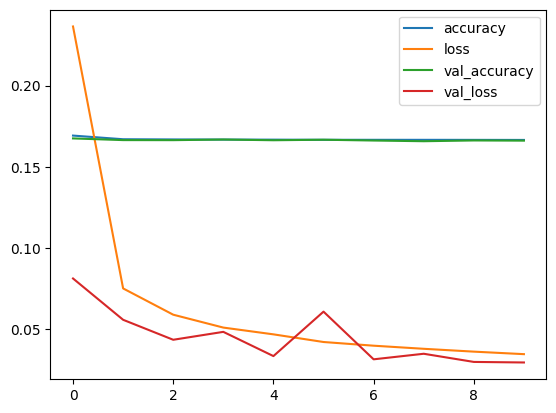

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step


c:\Users\kxl61517\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


In [6]:
predictions = model_results('Z:/training/models', 'Count', 'MultiPeakC1s', '140709', model_summary=False, plot_model=False, predict_data = predict_data)

In [22]:
data_numpy = predict_data.as_numpy_iterator()
current_slice = next(data_numpy)
print(current_slice[1])
get_xsw_profile(current_slice[0], current_slice[1][0], True)

[[[3.00000000e+00]
  [2.55214930e-01]
  [8.31595957e-01]
  [6.27561271e-01]
  [2.23760799e-01]
  [6.19042069e-02]
  [8.78381431e-01]
  [1.58709571e-01]
  [7.76125431e-01]
  [8.87237370e-01]
  [2.58789927e-01]
  [5.84322572e-01]
  [4.83048320e-01]
  [7.89626479e-01]
  [3.94666851e-01]
  [5.98952949e-01]
  [5.22041738e-01]
  [2.39393651e-01]
  [9.53887165e-01]
  [9.90999401e-01]
  [5.59561374e-03]
  [1.99296013e-01]
  [8.79149318e-01]
  [9.34731841e-01]
  [8.69018972e-01]
  [2.58485749e-02]
  [5.34984946e-01]
  [6.85647905e-01]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]
  [0.00000000e+00]]

 [[4.00000000e+00]
  [6.35348439e-01]
  [3.86070132e-01]
  [4.15898636e-02]
  [5.34724653e-01]
  [4.16190743e-01]
  [3.17263

ValueError: Error on input data

In [ ]:
with open('Z:/training/models/PosTrainHistory-300615.pkl', 'rb') as file:
    pos_history = pickle.load(file)

with open('Z:/training/models/GaussTrainHistory-010703.pkl', 'rb') as file:
    gauss_history = pickle.load(file)    #

with open('Z:/training/models/AsymmTrainHistory-0706.pkl', 'rb') as file:
    asymm_history = pickle.load(file)

with open('Z:/training/models/LorentzTrainHistory-300621.pkl', 'rb') as file:
    lorentz_history = pickle.load(file)

with open('Z:/training/models/StepTrainHistory-010714.pkl', 'rb') as file:
    step_history = pickle.load(file)

with open('Z:/training/models/IntensityTrainHistory-010720.pkl', 'rb') as file:
    intensity_history = pickle.load(file)

#with open('Z:/training/models/AllTrainHistory-1206.pkl', 'rb') as file:
#    all_history = pickle.load(file)

#plt.subplots(1, 2, sharey = True)
#plt.subplot(1, 2, 1)
#plt.plot(all_history['loss'])
#plt.plot(all_history['val_loss'])
#plt.title('loss')
#plt.subplot(1, 2, 2)
#plt.plot(all_history['mse'])
#plt.plot(all_history['val_mse'])
#plt.title('mse')
#plt.show()

print(step_history)
plt.subplots(2, 3, sharey=True)
plt.subplot(2, 3, 1)
plt.plot(pos_history['loss'])
plt.plot(pos_history['val_loss'])
plt.title('position')
plt.ylim(0)
plt.subplot(2,3,2)
plt.plot(gauss_history['mse'])
plt.plot(gauss_history['val_mse'])
plt.title('gauss')
plt.ylim(0)
plt.subplot(2,3,3)
plt.plot(lorentz_history['mse'])
plt.plot(lorentz_history['val_mse'])
plt.title('lorentz')
plt.ylim(0)
plt.subplot(2,3,4)
plt.plot(asymm_history['mse'])
plt.plot(asymm_history['val_mse'])
plt.title('asymm')
plt.ylim(0)
plt.subplot(2,3,5)
plt.plot(step_history['mse'])
plt.plot(step_history['val_mse'])
plt.title('step')
plt.ylim(0)
plt.subplot(2,3,6)
plt.plot(intensity_history['mse'])
plt.plot(intensity_history['val_mse'])
plt.title('intensity')
plt.ylim(0, 0.1)
plt.autoscale()
plt.show()

#pos_model = tf.keras.models.load_model('Z:/training/models/2PeakC1sPosModel-300615.keras')
#count_model = tf.keras.models.load_model('Z:/training/models/MultiPeakC1sCountModel-020720.keras')
#gauss_model = tf.keras.models.load_model('Z:/training/models/1PeakC1sGaussModel-0606.keras')
#asymm_model = tf.keras.models.load_model('Z:/training/models/1PeakC1sAsymmModel-0706.keras')
#lorentz_model = tf.keras.models.load_model('Z:/training/models/1PeakC1sLorentzModel-0606.keras')
#step_model = tf.keras.models.load_model('Z:/training/models/1PeakC1sStepModel-0706.keras')
#intensity_model = tf.keras.models.load_model('Z:/training/models/1PeakC1sIntensityModel-0706.keras')
#all_model = tf.keras.models.load_model('Z:/training/models/1PeakC1sAllModel-1206.keras')

#pos_model.summary()
#count_model.summary()
#lorentz_model.summary()
#gauss_model.summary()
#asymm_model.summary()

#print(lorentz_model.get_layer('conv2d_3').get_config())

#keras.utils.plot_model(lorentz_model, show_shapes=True, show_layer_activations=True)

records_per_file = 10000
filename_format = '{}records{}.tfrecords'
num_files = 1
start_num = 0
filenames = [filename_format.format(records_per_file, i+1) for i in range(start_num, start_num + num_files , 1)]

file_dir = "Y:/MultiPeakC1sData"
file_paths = ['{}/{}'.format(file_dir, filename) for filename in filenames]
print(file_paths)

predict_files = tf.data.Dataset.from_tensor_slices(file_paths)
predict_data = predict_files.interleave(lambda filename: tf.data.TFRecordDataset(filename).prefetch(1000))
features_dict = {
    'xsw_curve': tf.io.FixedLenFeature(shape = (504,200,1), dtype = tf.float32),
    'cs_norm': tf.io.FixedLenFeature(shape = (46,1), dtype = tf.float32),
}

predict_data = predict_data.map(map_func = lambda serialized: tf.io.parse_single_example(serialized=serialized, features = features_dict))
count_predict_data = predict_data.map(map_func = lambda features:
                              (features['xsw_curve'],
                              tf.gather(features['cs_norm'], )
                              )
                              )
count_predict_data = count_predict_data.batch(250)

test_files = tf.data.Dataset.from_tensor_slices(file_paths)
block_length = 10
test_data = test_files.interleave(lambda filename: tf.data.TFRecordDataset(filename).prefetch(num_files * block_length))


features_dict = {
    'xsw_curve': tf.io.FixedLenFeature(shape = (504,200,1), dtype = tf.float32),
    'cs_norm': tf.io.FixedLenFeature(shape = (46,1), dtype = tf.float32),
}

test_data = test_data.map(map_func = lambda serialized: tf.io.parse_single_example(serialized=serialized, features = features_dict))
xsw = test_data.map(map_func = lambda features:(features['xsw_curve']))
cs = test_data.map(map_func = lambda features:(features['cs_norm']))
pos_test_data = test_data.map(map_func = lambda features:
                      (features['xsw_curve'],
                       ((tf.gather``))
                      )
                   )

pos_test_data = pos_test_data.batch(250)

gauss_test_data = test_data.map(map_func = lambda features:
                      (features['xsw_curve'],
                       tf.gather(features['cs_norm'], 11)
                      )
                   )
gauss_test_data = gauss_test_data.batch(250)

asymm_test_data = test_data.map(map_func = lambda features:
                      (features['xsw_curve'],
                       tf.gather(features['cs_norm'], 13)
                      )
                  )
asymm_test_data = asymm_test_data.batch(250)

lorentz_test_data = test_data.map(map_func = lambda features:
                      (features['xsw_curve'],
                       tf.gather(features['cs_norm'], 12)
                      )
                   )
lorentz_test_data = lorentz_test_data.batch(250)

step_test_data = test_data.map(map_func = lambda features:
                      (features['xsw_curve'],
                       tf.gather(features['cs_norm'], 14)
                      )
                   )
step_test_data = step_test_data.batch(250)

intensity_test_data = test_data.map(map_func = lambda features:
                      (features['xsw_curve'],
                       tf.gather(features['cs_norm'], 15)
                      )
                   )
intensity_test_data = intensity_test_data.batch(250)

all_test_data = test_data.map(map_func = lambda features:
                              (features['xsw_curve'],
                              tf.gather(features['cs_norm'], (10, 11, 12, 13, 14, 15))
                              )
                              )
all_test_data = all_test_data.batch(250)

print(next(count_predict_data.as_numpy_iterator()))

count_predictions = count_model.predict(count_predict_data)
count_predictions

predict_data_np = np.array(next(count_predict_data.as_numpy_iterator()))
print(predict_data_np.shape)

#for i in range(80):
#    print(all_predictions[i], next(predict_data_np)[1])
#    print('##############')

predictions = np.array(predictions)
print(predictions[:,0])
unsummed = np.array(next(xsw.as_numpy_iterator()).reshape(504, 200))
sum_spectra = [0]*200
for i in range(504):
    sum_spectra = sum_spectra + unsummed[i]

plt.plot(sum_spectra)

{'loss': [0.25000646710395813, 0.25000235438346863, 0.2500017285346985, 0.2500017583370209, 0.25000178813934326, 0.2500019669532776, 0.25000131130218506, 0.2500017583370209, 0.25000184774398804, 0.25000232458114624], 'mse': [0.08335655182600021, 0.08335229754447937, 0.08335185050964355, 0.08335190266370773, 0.08335186541080475, 0.0833522230386734, 0.0833519846200943, 0.08335216343402863, 0.08335200697183609, 0.08335226774215698], 'val_loss': [0.25011011958122253, 0.2501109540462494, 0.2501099407672882, 0.25010985136032104, 0.25011011958122253, 0.2501097619533539, 0.2501104176044464, 0.2501105070114136, 0.25011005997657776, 0.2501102387905121], 'val_mse': [0.08337711542844772, 0.08337803930044174, 0.08337689191102982, 0.08337681740522385, 0.08337707817554474, 0.08337676525115967, 0.08337733149528503, 0.08337754011154175, 0.08337696641683578, 0.08337728679180145]}
